# Tutorial 03: First-Order Optimizers (Momentum, RMSprop, Adam) & Schedulers

### Learning Objectives
1. Understand why vanilla SGD oscillates along ill-conditioned loss ravines.
2. Master Exponential Moving Averages of gradients (Momentum) and squared gradients (RMSprop).
3. Implement Adam's bias correction mechanism.
4. Compare Cosine Annealing vs. Exponential learning rate schedules.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.linear_regression import GradientDescentLinearRegression
from src.schedulers import ConstantLR, StepLR, ExponentialLR, CosineAnnealingLR

## 1. Comparing Optimizers on Ill-Conditioned Surfaces
We generate synthetic data with disparate feature variances (condition number $\kappa > 100$).

In [2]:
np.random.seed(42)
N = 500
# Feature 0 has scale 10.0, Feature 1 has scale 0.1 (eccentric quadratic bowl)
X_ill = np.column_stack([
    np.random.normal(0, 10.0, N),
    np.random.normal(0, 0.1, N),
    np.random.normal(0, 1.0, N)
])
y_ill = 2.0 * X_ill[:, 0] + 5.0 * X_ill[:, 1] - 3.0 * X_ill[:, 2] + np.random.normal(0, 0.5, N)

opts = ["sgd", "momentum", "rmsprop", "adam"]
trained_models = {}

for opt in opts:
    m = GradientDescentLinearRegression(lr=0.01, n_iters=250, optimizer=opt, seed=42)
    m.fit(X_ill, y_ill)
    trained_models[opt] = m
    print(f"Optimizer {opt.upper():<10} -> Final MSE: {m.loss_history_[-1]:.4f}")

Optimizer SGD        -> Final MSE: 0.4509
Optimizer MOMENTUM   -> Final MSE: 0.3319
Optimizer RMSPROP    -> Final MSE: 0.6540
Optimizer ADAM       -> Final MSE: 10.9622


## 2. Convergence Trajectories Plot

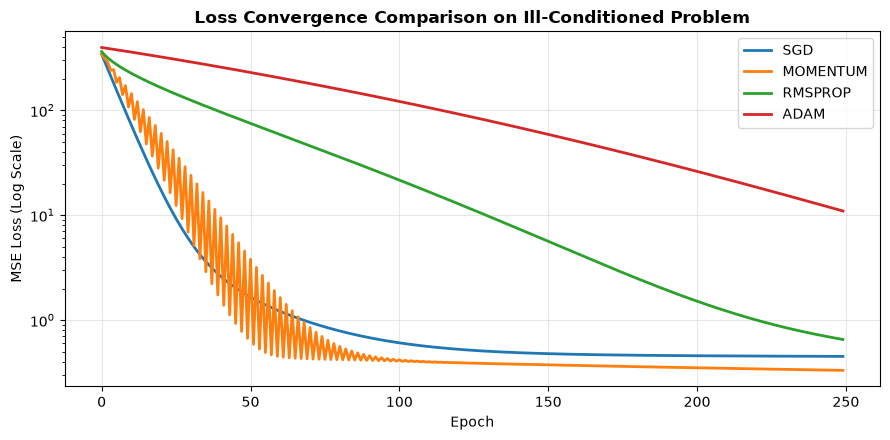

In [3]:
plt.figure(figsize=(9, 4.5))
for opt, m in trained_models.items():
    plt.plot(m.loss_history_, lw=2, label=opt.upper())
plt.yscale("log")
plt.title("Loss Convergence Comparison on Ill-Conditioned Problem", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (Log Scale)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Learning Rate Schedulers
We compare Constant learning rate against Cosine Annealing:
$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\left(\frac{\pi t}{T_{\max}}\right)\right)$$

In [4]:
sched_const = ConstantLR(initial_lr=0.05)
sched_cosine = CosineAnnealingLR(initial_lr=0.05, T_max=250, eta_min=1e-4)

m_const = GradientDescentLinearRegression(lr=0.05, n_iters=250, scheduler=sched_const, optimizer="adam")
m_cosine = GradientDescentLinearRegression(lr=0.05, n_iters=250, scheduler=sched_cosine, optimizer="adam")

m_const.fit(X_ill, y_ill)
m_cosine.fit(X_ill, y_ill)

print(f"Constant LR Final Loss:        {m_const.loss_history_[-1]:.5f}")
print(f"Cosine Annealing Final Loss:  {m_cosine.loss_history_[-1]:.5f}")

Constant LR Final Loss:        0.24406
Cosine Annealing Final Loss:  0.33704
